# Somalia Displacement Forecasting


### Notebook 1 —  EXPLORATORY DATA ANALYSIS (EDA)

In [53]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

ROOT = Path('..').resolve()
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
print('Setup complete.')

Setup complete.


In [55]:
# ──  colour palette — used in every figure 
MODEL_COLORS = {
    'Random Walk'    : '#888888',
    'AR(1)'          : '#4e79a7',
    'Rolling Avg (4)': '#76b7b2',
    'Rolling Avg (8)': '#59a14f',
    'Rolling Avg(12)': '#b07aa1',
    'Long Run Mean'  : '#bab0ac',
    'Long Run Median': '#d3d3d3',
    'GBM (lags=2)'   : '#f28e2b',
    'GBM (lags=5)'   : '#e05c1a',
    'GBM (lags=8)'   : '#c0392b',
    'LSTM (seq=2)'   : '#9b59b6',
    'LSTM (seq=5)'   : '#7d3c98',
    'LSTM (seq=8)'   : '#5b2c6f',
    'Hurdle (lags=2)': '#1abc9c',
    'Hurdle (lags=5)': '#17a589',
    'Hurdle (lags=8)': '#148f77',
    'Z&T: Bayesian DL-DLM': '#2c3e50',
}


---
##   Load the Panel and Basic Checks

In [ ]:
# ── Load main panel 
panel = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel.parquet')

print(f'Rows         : {len(panel):,}  (expected 25,382)')
print(f'Districts    : {panel["district"].nunique()}  (expected 74)')
print(f'Weeks        : {panel["week_start"].nunique()}  (expected 343)')
print(f'Date range   : {panel["week_start"].min().date()} → {panel["week_start"].max().date()}')
print(f'Duplicates   : {panel.duplicated(["district","week_start"]).sum()}  (expected 0)')
print(f'Missing vals : {panel.isnull().sum().sum()}  (expected 0)')
print(f'Columns      : {panel.columns.tolist()}')
panel.head(3)

Rows         : 25,382  (expected 25,382)
Districts    : 74  (expected 74)
Weeks        : 343  (expected 343)
Date range   : 2017-01-02 → 2023-07-24
Duplicates   : 0  (expected 0)
Missing vals : 0  (expected 0)
Columns      : ['district', 'week_start', 'outflows', 'battles', 'explosions', 'strategic_dev', 'viol_civ', 'y', 'week_num']


,district,week_start,outflows,battles,explosions,strategic_dev,viol_civ,y,week_num
0,Adan Yabaal,2017-01-02,0,0,0,0,0,0.0,1
1,Adan Yabaal,2017-01-09,0,0,0,0,0,0.0,2
2,Adan Yabaal,2017-01-16,0,0,0,0,0,0.0,3


---
## Displacement Statistics

In [57]:
# ── Outflow summary ───────────────────────────────────────────────────────────
total_out = panel['outflows'].sum()
zero_pct  = (panel['outflows'] == 0).mean() * 100
nonzero   = panel[panel['outflows'] > 0]['outflows']

print(f'Total individuals displaced : {total_out:,}  (Z&T ≈ 8 million)')
print(f'Zero-outflow cells          : {zero_pct:.1f}%')
print(f'Non-zero median             : {nonzero.median():,.0f}')
print(f'Non-zero max                : {nonzero.max():,}')

print('\nTop 10 origin districts (fled FROM):')
top = panel.groupby('district')['outflows'].sum().sort_values(ascending=False)
print(top.head(10).apply(lambda x: f'{x:>10,}').to_string())

Total individuals displaced : 8,136,118  (Z&T ≈ 8 million)
Zero-outflow cells          : 32.2%
Non-zero median             : 48
Non-zero max                : 257,106

Top 10 origin districts (fled FROM):
district
Belet Weyne       1,030,000
Baydhaba            428,344
Afgooye             359,764
Jowhar              329,486
Kurtunwaarey        311,104
Dhuusamarreeb       305,941
Diinsoor            302,027
Laas Caanood        292,094
Baardheere          290,651
Qansax Dheere       280,006


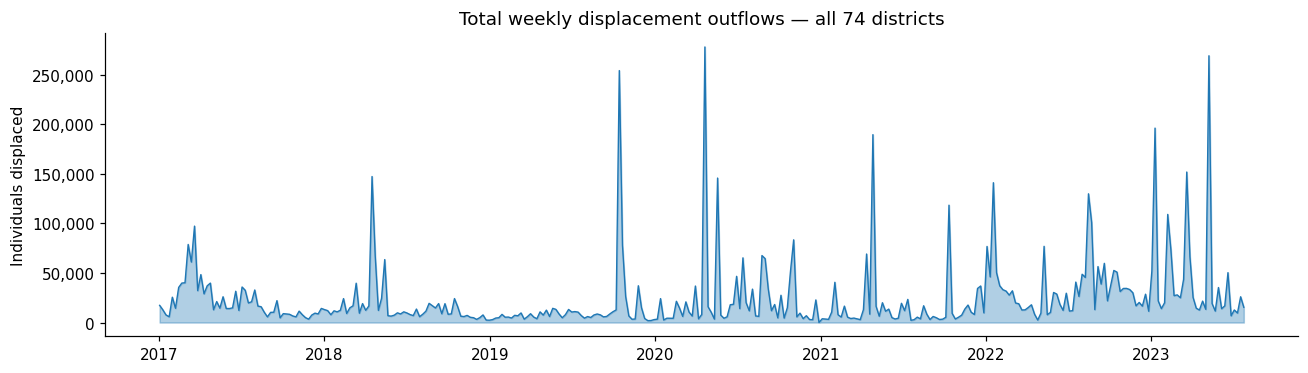

In [58]:
# ── Figure: total weekly outflows ─────────────────────────────────────────────
weekly = panel.groupby('week_start')['outflows'].sum()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(weekly.index, weekly.values, alpha=0.35, color='#1f77b4')
ax.plot(weekly.index, weekly.values, lw=0.9, color='#1f77b4')
ax.set_title('Total weekly displacement outflows — all 74 districts')
ax.set_ylabel('Individuals displaced')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout(); plt.show()

---
## Section 3 — Target Variable  y = log(1 + outflows)

y = log(1 + outflows):
count    25382.0000
mean         2.7867
std          2.3701
min          0.0000
25%          0.0000
50%          2.8904
75%          4.5643
max         12.4572


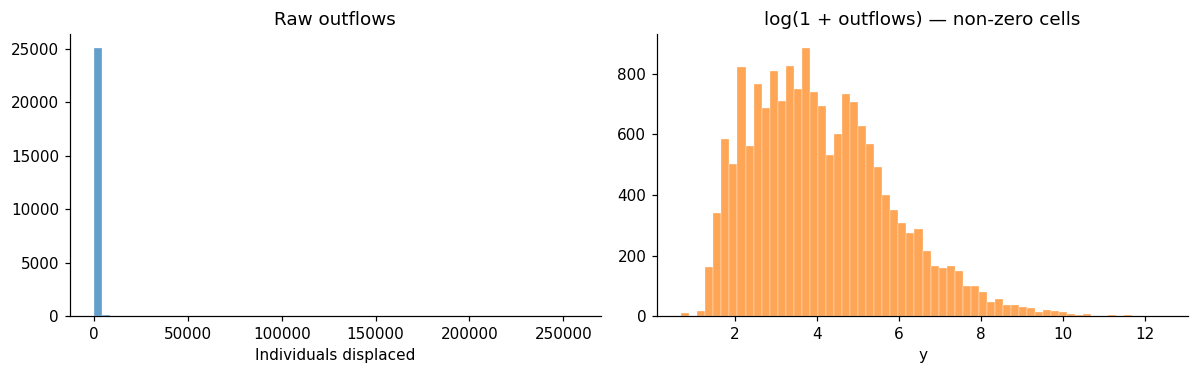

In [60]:
# ── Distribution of y ─────────────────────────────────────────────────────────
print('y = log(1 + outflows):')
print(panel['y'].describe().round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(panel['outflows'], bins=60, color='#1f77b4', alpha=0.7, edgecolor='white', lw=0.3)
axes[0].set_title('Raw outflows')
axes[0].set_xlabel('Individuals displaced')
axes[1].hist(panel[panel['y'] > 0]['y'], bins=60, color='#ff7f0e', alpha=0.7, edgecolor='white', lw=0.3)
axes[1].set_title('log(1 + outflows) — non-zero cells')
axes[1].set_xlabel('y')
plt.tight_layout(); plt.show()

---
##   Conflict Event Statistics

In [61]:
# ── Conflict event counts by type ─────────────────────────────────────────────
conflict_cols = ['battles', 'explosions', 'strategic_dev', 'viol_civ']
totals = panel[conflict_cols].sum()
grand  = totals.sum()

print('ACLED conflict events by type:')
for col, val in totals.items():
    print(f'  {col:<16}: {val:>6,}  ({val/grand*100:.1f}%)')
print(f'  {"TOTAL":<16}: {grand:>6,}  (Z&T ≈ 19,000)')

print('\nCorrelation with y:')
for col in conflict_cols:
    print(f'  corr(y, {col:<16}) = {panel["y"].corr(panel[col]):+.4f}')

ACLED conflict events by type:
  battles         : 10,974  (53.6%)
  explosions      :  4,683  (22.9%)
  strategic_dev   :  1,364  (6.7%)
  viol_civ        :  3,443  (16.8%)
  TOTAL           : 20,464  (Z&T ≈ 19,000)

Correlation with y:
  corr(y, battles         ) = +0.1548
  corr(y, explosions      ) = +0.1213
  corr(y, strategic_dev   ) = +0.0892
  corr(y, viol_civ        ) = +0.0641


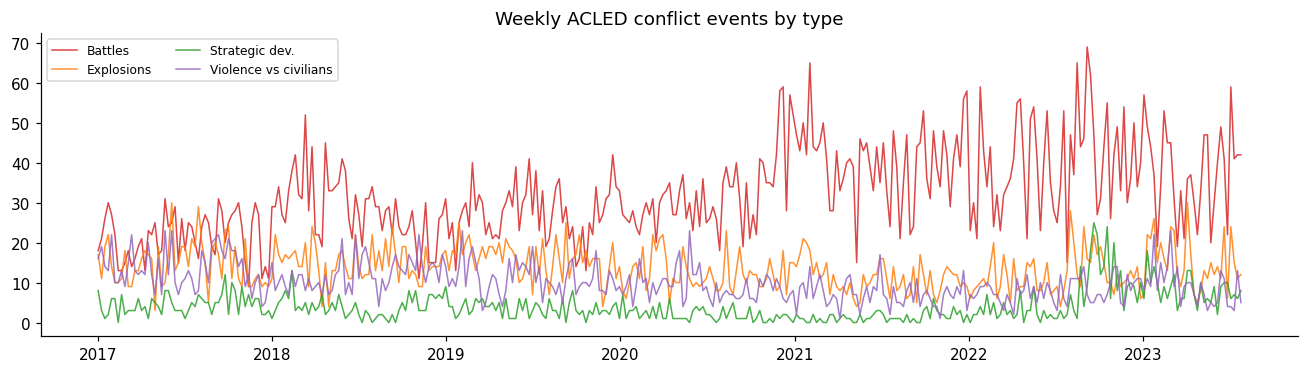

In [62]:
# ── Figure: weekly conflict events ────────────────────────────────────────────
wc = panel.groupby('week_start')[conflict_cols].sum()
colours = ['#d62728','#ff7f0e','#2ca02c','#9467bd']
labels  = ['Battles','Explosions','Strategic dev.','Violence vs civilians']
fig, ax = plt.subplots(figsize=(12, 3.5))
for col, c, lab in zip(conflict_cols, colours, labels):
    ax.plot(wc.index, wc[col], lw=1.0, color=c, alpha=0.85, label=lab)
ax.set_title('Weekly ACLED conflict events by type')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

---
##  Geographic Distribution: Displacement and Conflict Across Somalia

Choropleth maps of all 74 districts.  
**Left:** total displacement outflows (people who fled FROM each district, 2017–2023).  
**Right:** total ACLED conflict events in each district over the same period.  

Colour scales are consistent throughout the notebook:  
- Orange/red = displacement intensity  
- Blue/teal = conflict intensity

Districts matched: 74/74


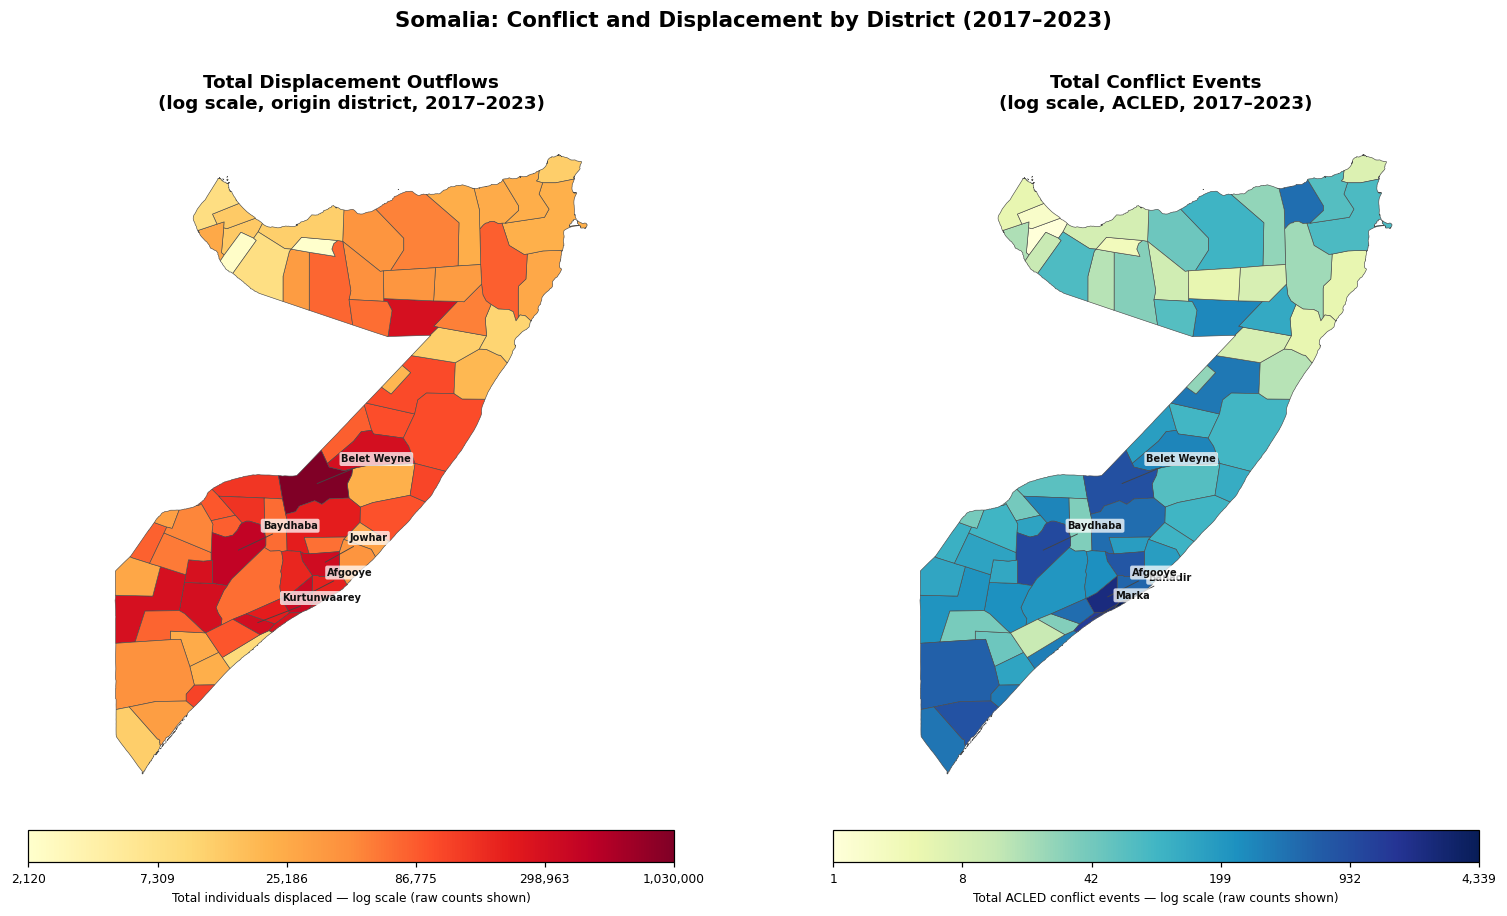

Map saved — colours are log-normalised so all districts are visible


In [64]:
# ── Somalia choropleth maps — log-normalised colour scale ─────────────────────
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable

CANONICAL_TO_GADM = {
    'Adan Yabaal': 'Aadan',      'Baardheere': 'Baar-Dheere',
    'Banadir': 'Mogadisho',      'Bandarbeyla': 'Bander-Beyla',
    'Baydhaba': 'Baydhabo',      'Belet Weyne': 'BeledWeyn',
    'Belet Xaawo': 'BeledXaawo', 'Borama': 'Boorama',
    'Bossaso': 'Bosaaso',        'Bulo Burto': 'BuuloBurdo',
    'Burco': 'Burao',            'Buur Hakaba': 'BuurXakaba',
    'Cabudwaaq': 'Caabudwaaq',   'Caluula': 'Calawla',
    'Ceel Afweyn': 'Ceel-Afwein','Ceel Barde': 'CeelBarde',
    'Ceel Buur': 'CeelBuur',     'Ceel Dheer': 'CeelDheer',
    'Ceel Waaq': 'CeelWaaq',     'Dhuusamarreeb': 'Dhuusamareeb',
    'Doolow': 'Dolow',           'Gaalkacyo': 'Gaalkacayo',
    'Galdogob': 'Goldogob',      'Garbahaarey': 'Garbahaaray',
    'Gebiley': 'Gabiley',        'Jowhar': 'Jawhar',
    'Kurtunwaarey': 'Kuntuwaaray','Laas Caanood': 'Lascaanod',
    'Laasqoray': 'Badhan',       'Lughaye': 'Lughaya',
    'Luuq': 'Luuk',              'Owdweyne': 'Oodweyne',
    'Qansax Dheere': 'QansaxDheere','Rab Dhuure': 'RabDhuure',
    'Sablaale': 'Sablale',       'Sheikh': 'Sheekh',
    'Tayeeglow': 'Tiyeeglow',    'Waajid': 'Wajid',
    'Wanla Weyn': 'WanlaWeyn',
}

# Aggregate stats from panel
conflict_cols = ['battles', 'explosions', 'strategic_dev', 'viol_civ']
stats = panel.groupby('district').agg(
    total_outflows =('outflows', 'sum'),
    battles        =('battles',  'sum'),
    explosions     =('explosions','sum'),
    strategic_dev  =('strategic_dev','sum'),
    viol_civ       =('viol_civ',  'sum'),
).reset_index()
stats['total_conflict'] = stats[conflict_cols].sum(axis=1)
stats['gadm_name']      = stats['district'].map(lambda d: CANONICAL_TO_GADM.get(d, d))

gdf        = gpd.read_file(ROOT / 'data' / 'raw' / 'somalia_admin2.geojson')
gdf_merged = gdf.merge(stats, left_on='NAME_2', right_on='gadm_name', how='left')
print(f'Districts matched: {gdf_merged["district"].notna().sum()}/74')

# ── Log-normalise values ──────────────────────────────────────────────────────
# Add 1 so log(1+x) is defined for zeros; floor at 1 for log scale
gdf_merged['log_outflows'] = np.log1p(gdf_merged['total_outflows'].fillna(0))
gdf_merged['log_conflict'] = np.log1p(gdf_merged['total_conflict'].fillna(0))

DISP_CMAP     = 'YlOrRd'
CONFLICT_CMAP = 'YlGnBu'
BG_COLOR      = '#f0f4f8'
BORDER_COLOR  = '#4a4a4a'

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax in axes:
    ax.set_facecolor(BG_COLOR)
    ax.set_aspect('equal')

# ── Left: displacement (log scale) ───────────────────────────────────────────
vmin_d = gdf_merged['log_outflows'].min()
vmax_d = gdf_merged['log_outflows'].max()
norm_d = mcolors.Normalize(vmin=vmin_d, vmax=vmax_d)
cmap_d = plt.get_cmap(DISP_CMAP)

gdf_merged['color_d'] = gdf_merged['log_outflows'].apply(
    lambda v: cmap_d(norm_d(v)) if pd.notna(v) else (0.85, 0.85, 0.85, 1))
gdf_merged.plot(color=gdf_merged['color_d'].tolist(),
                linewidth=0.4, edgecolor=BORDER_COLOR, ax=axes[0])

# Manual colourbar with original-scale tick labels
sm_d = ScalarMappable(cmap=cmap_d, norm=norm_d)
sm_d.set_array([])
cbar_d = fig.colorbar(sm_d, ax=axes[0], orientation='horizontal',
                       shrink=0.7, pad=0.03)
# Convert log ticks back to original scale for readable labels
log_ticks_d = np.linspace(vmin_d, vmax_d, 6)
cbar_d.set_ticks(log_ticks_d)
cbar_d.set_ticklabels([f'{int(np.expm1(v)):,}' for v in log_ticks_d], fontsize=8)
cbar_d.set_label('Total individuals displaced — log scale (raw counts shown)', fontsize=8)

# Label top 5 districts
gdf_proj = gdf.to_crs(epsg=4326)
top5_disp = stats.nlargest(5, 'total_outflows')
for _, row in top5_disp.iterrows():
    gadm_n = CANONICAL_TO_GADM.get(row['district'], row['district'])
    geom   = gdf_proj[gdf_proj['NAME_2'] == gadm_n]
    if len(geom) == 0: continue
    cx = float(geom.centroid.x.values[0])
    cy = float(geom.centroid.y.values[0])
    axes[0].annotate(row['district'], xy=(cx, cy), xytext=(cx+0.6, cy+0.5),
        fontsize=6.5, fontweight='bold', color='#111',
        arrowprops=dict(arrowstyle='-', color='#444', lw=0.6),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75, lw=0))
axes[0].set_title('Total Displacement Outflows\n(log scale, origin district, 2017–2023)',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].axis('off')

# ── Right: conflict (log scale) ──────────────────────────────────────────────
vmin_c = gdf_merged['log_conflict'].min()
vmax_c = gdf_merged['log_conflict'].max()
norm_c = mcolors.Normalize(vmin=vmin_c, vmax=vmax_c)
cmap_c = plt.get_cmap(CONFLICT_CMAP)

gdf_merged['color_c'] = gdf_merged['log_conflict'].apply(
    lambda v: cmap_c(norm_c(v)) if pd.notna(v) else (0.85, 0.85, 0.85, 1))
gdf_merged.plot(color=gdf_merged['color_c'].tolist(),
                linewidth=0.4, edgecolor=BORDER_COLOR, ax=axes[1])

sm_c = ScalarMappable(cmap=cmap_c, norm=norm_c)
sm_c.set_array([])
cbar_c = fig.colorbar(sm_c, ax=axes[1], orientation='horizontal',
                       shrink=0.7, pad=0.03)
log_ticks_c = np.linspace(vmin_c, vmax_c, 6)
cbar_c.set_ticks(log_ticks_c)
cbar_c.set_ticklabels([f'{int(np.expm1(v)):,}' for v in log_ticks_c], fontsize=8)
cbar_c.set_label('Total ACLED conflict events — log scale (raw counts shown)', fontsize=8)

top5_conf = stats.nlargest(5, 'total_conflict')
for _, row in top5_conf.iterrows():
    gadm_n = CANONICAL_TO_GADM.get(row['district'], row['district'])
    geom   = gdf_proj[gdf_proj['NAME_2'] == gadm_n]
    if len(geom) == 0: continue
    cx = float(geom.centroid.x.values[0])
    cy = float(geom.centroid.y.values[0])
    axes[1].annotate(row['district'], xy=(cx, cy), xytext=(cx+0.6, cy+0.5),
        fontsize=6.5, fontweight='bold', color='#111',
        arrowprops=dict(arrowstyle='-', color='#444', lw=0.6),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75, lw=0))
axes[1].set_title('Total Conflict Events\n(log scale, ACLED, 2017–2023)',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].axis('off')

fig.suptitle('Somalia: Conflict and Displacement by District (2017–2023)',
             fontsize=14, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(ROOT / 'results' / 'tables' / 'fig_somalia_maps.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Map saved — colours are log-normalised so all districts are visible')

---
### EDA Figures — Temporal Distribution and Top Districts 



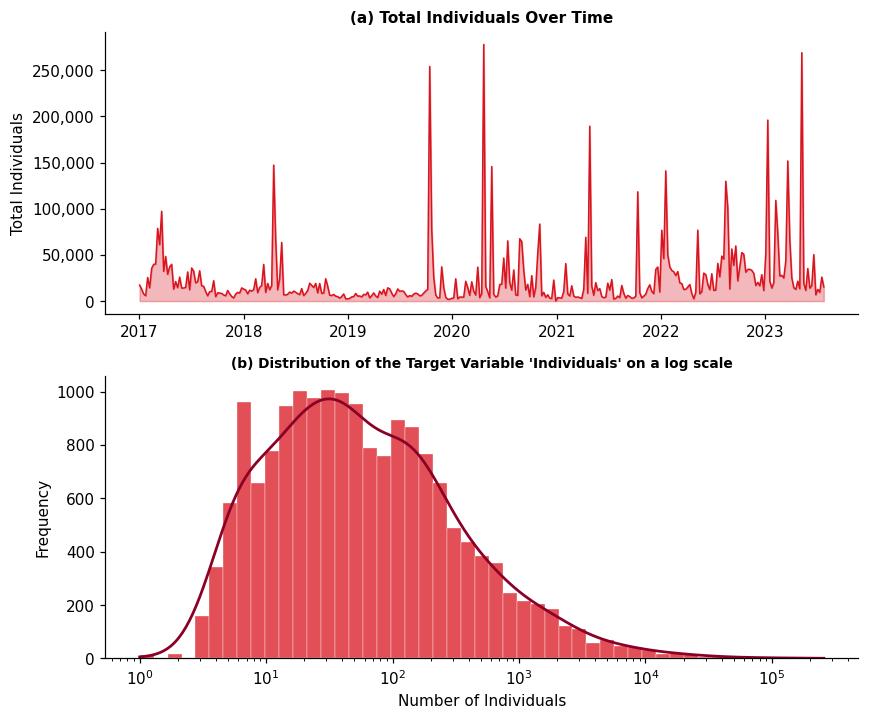

Saved fig_eda_target.png


In [76]:
# ── Fig 3: Displacement — temporal and distributional EDA ───────────────────
import matplotlib
import numpy as np
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

# Pick a warm orange-red from YlOrRd — matches the displacement bars in Fig 4b
DISP_COLOR = matplotlib.colormaps['YlOrRd'](0.78)
DISP_DARK  = matplotlib.colormaps['YlOrRd'](0.98)   # dark red for KDE line

fig3, axes3 = plt.subplots(2, 1, figsize=(8, 7))

# (a) Total weekly displacement over time
weekly = panel.groupby('week_start')['outflows'].sum()
axes3[0].fill_between(weekly.index, weekly.values, alpha=0.30, color=DISP_COLOR)
axes3[0].plot(weekly.index, weekly.values, lw=1.0, color=DISP_COLOR)
axes3[0].set_title('(a) Total Individuals Over Time', fontsize=10, fontweight='bold')
axes3[0].set_ylabel('Total Individuals')
axes3[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes3[0].spines['top'].set_visible(False)
axes3[0].spines['right'].set_visible(False)

# (b) Distribution of outflows — log x-axis
y_pos    = panel['outflows'].values
y_pos    = y_pos[y_pos > 0]
log_bins = np.logspace(0, np.log10(y_pos.max()), 50)
axes3[1].hist(y_pos, bins=log_bins, color=DISP_COLOR, alpha=0.75,
              edgecolor='white', linewidth=0.3)
axes3[1].set_xscale('log')
axes3[1].set_title(
    "(b) Distribution of the Target Variable 'Individuals' on a log scale",
    fontsize=9, fontweight='bold')
axes3[1].set_xlabel('Number of Individuals')
axes3[1].set_ylabel('Frequency')
axes3[1].text(0.5, -0.14,
    '',
    transform=axes3[1].transAxes, ha='center', fontsize=8, color='#555')
axes3[1].spines['top'].set_visible(False)
axes3[1].spines['right'].set_visible(False)

# KDE overlay
log_y   = np.log10(y_pos)
kde     = gaussian_kde(log_y, bw_method=0.25)
xs_log  = np.linspace(log_y.min(), log_y.max(), 400)
xs_orig = 10 ** xs_log
n_bins  = len(log_bins) - 1
kde_cts = kde(xs_log) * len(y_pos) * (log_y.max() - log_y.min()) / n_bins
axes3[1].plot(xs_orig, kde_cts, color=DISP_DARK, lw=1.8)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig3.savefig(ROOT / 'results' / 'tables' / 'fig_eda_target.png',
             dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved fig_eda_target.png')


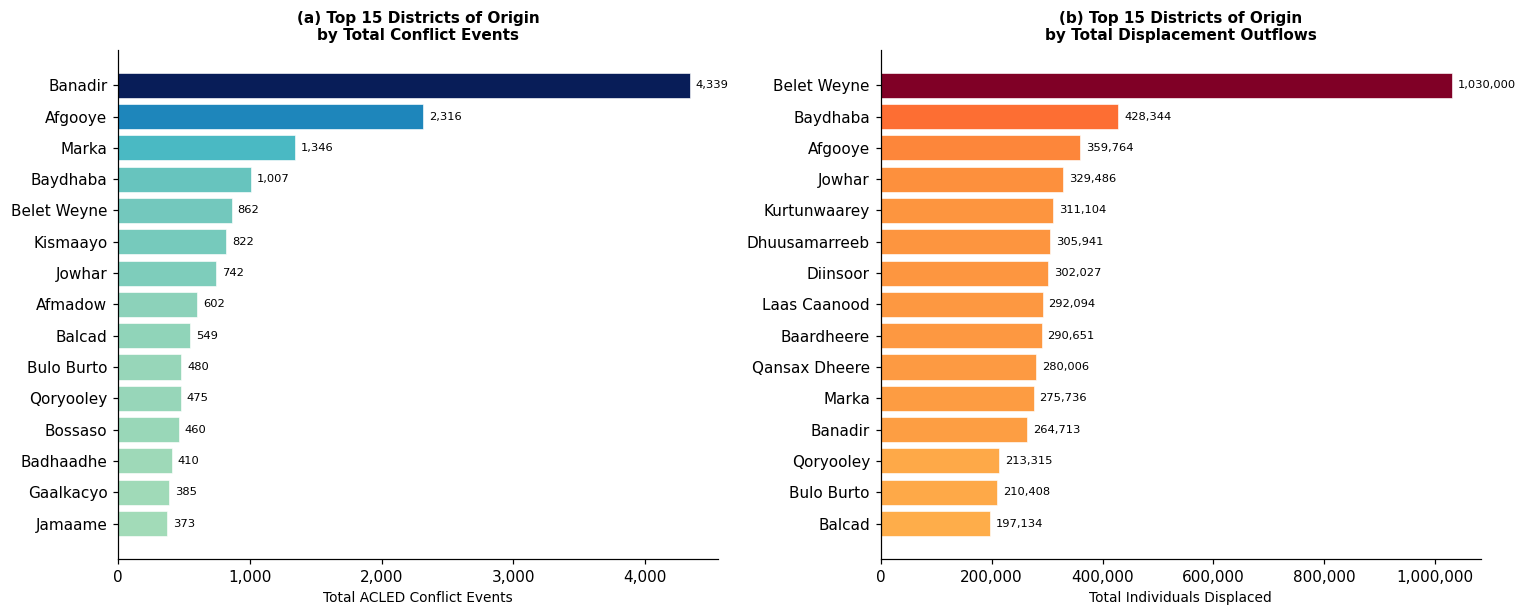

Saved fig_eda_geographic.png


In [71]:
# ── Fig 4: Geographic concentration — top 15 origin districts ────────────────
import matplotlib
import matplotlib.colors as mcolors

# Aggregate per district (uses variables already computed in the map cell)
conflict_cols_4 = ['battles', 'explosions', 'strategic_dev', 'viol_civ']
dist_stats = panel.groupby('district').agg(
    total_outflows  = ('outflows', 'sum'),
    n_records       = ('outflows', 'count'),
).reset_index()
dist_stats['total_conflict'] = (
    panel.groupby('district')[conflict_cols_4].sum().sum(axis=1).values
)

top15_conf = dist_stats.nlargest(15, 'total_conflict').sort_values('total_conflict')
top15_disp = dist_stats.nlargest(15, 'total_outflows').sort_values('total_outflows')

def bar_colors(values, cmap_name):
    """Map sorted values to colormap — lowest = lightest, highest = darkest."""
    norm = mcolors.Normalize(vmin=0, vmax=values.max())
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    return [cmap(norm(v) * 0.75 + 0.25) for v in values]  # avoid very light end

fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 6))

# (a) Top 15 districts by total conflict events — YlGnBu (matches conflict map)
colors_c = bar_colors(top15_conf['total_conflict'].values, 'YlGnBu')
bars_c   = ax4a.barh(top15_conf['district'], top15_conf['total_conflict'],
                     color=colors_c, edgecolor='white', linewidth=0.4)
ax4a.set_xlabel('Total ACLED Conflict Events', fontsize=9)
ax4a.set_title('(a) Top 15 Districts of Origin\nby Total Conflict Events',
               fontsize=10, fontweight='bold')
ax4a.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax4a.spines['top'].set_visible(False)
ax4a.spines['right'].set_visible(False)

# Add value labels
for bar, val in zip(bars_c, top15_conf['total_conflict']):
    ax4a.text(bar.get_width() + top15_conf['total_conflict'].max() * 0.01,
              bar.get_y() + bar.get_height() / 2,
              f'{int(val):,}', va='center', fontsize=7.5)

# (b) Top 15 districts by total outflows — YlOrRd (matches displacement map)
colors_d = bar_colors(top15_disp['total_outflows'].values, 'YlOrRd')
bars_d   = ax4b.barh(top15_disp['district'], top15_disp['total_outflows'],
                     color=colors_d, edgecolor='white', linewidth=0.4)
ax4b.set_xlabel('Total Individuals Displaced', fontsize=9)
ax4b.set_title('(b) Top 15 Districts of Origin\nby Total Displacement Outflows',
               fontsize=10, fontweight='bold')
ax4b.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax4b.spines['top'].set_visible(False)
ax4b.spines['right'].set_visible(False)

# Add value labels
for bar, val in zip(bars_d, top15_disp['total_outflows']):
    ax4b.text(bar.get_width() + top15_disp['total_outflows'].max() * 0.01,
              bar.get_y() + bar.get_height() / 2,
              f'{int(val):,}', va='center', fontsize=7.5)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig4.savefig(ROOT / 'results' / 'tables' / 'fig_eda_geographic.png',
             dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved fig_eda_geographic.png')


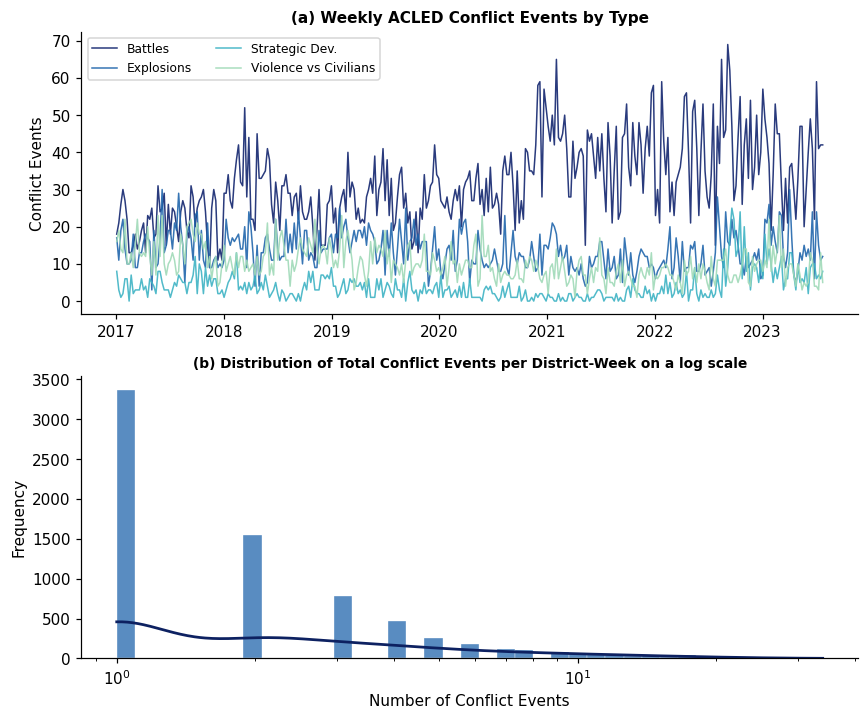

Saved fig_eda_conflict.png


In [77]:
# ── Fig 5: Conflict — temporal and distributional EDA ───────────────────────
import matplotlib
from scipy.stats import gaussian_kde

# Four shades of YlGnBu — matches conflict bars in Fig 4a (darkest = most intense)
conflict_cols_5 = ['battles', 'explosions', 'strategic_dev', 'viol_civ']
conf_palette = {
    'battles'     : matplotlib.colormaps['YlGnBu'](0.95),
    'explosions'  : matplotlib.colormaps['YlGnBu'](0.73),
    'strategic_dev': matplotlib.colormaps['YlGnBu'](0.51),
    'viol_civ'    : matplotlib.colormaps['YlGnBu'](0.32),
}
CONF_FILL = matplotlib.colormaps['YlGnBu'](0.73)   # mid-blue for histogram
CONF_DARK = matplotlib.colormaps['YlGnBu'](0.98)   # darkest for KDE line
conf_labels = {
    'battles'     : 'Battles',
    'explosions'  : 'Explosions',
    'strategic_dev': 'Strategic Dev.',
    'viol_civ'    : 'Violence vs Civilians',
}

fig5, axes5 = plt.subplots(2, 1, figsize=(8, 7))

# (a) Weekly conflict events by type
wc5 = panel.groupby('week_start')[conflict_cols_5].sum()
for col, color in conf_palette.items():
    axes5[0].plot(wc5.index, wc5[col], lw=1.0, color=color,
                  alpha=0.9, label=conf_labels[col])
axes5[0].set_title('(a) Weekly ACLED Conflict Events by Type',
                   fontsize=10, fontweight='bold')
axes5[0].set_ylabel('Conflict Events')
axes5[0].legend(fontsize=8, ncol=2)
axes5[0].spines['top'].set_visible(False)
axes5[0].spines['right'].set_visible(False)

# (b) Distribution of per-district-week conflict events — log x-axis
conf_row = panel[conflict_cols_5].sum(axis=1).values
conf_pos = conf_row[conf_row > 0]
log_bins_c = np.logspace(0, np.log10(conf_pos.max()), 40)
axes5[1].hist(conf_pos, bins=log_bins_c, color=CONF_FILL, alpha=0.75,
              edgecolor='white', linewidth=0.3)
axes5[1].set_xscale('log')
axes5[1].set_title(
    "(b) Distribution of Total Conflict Events per District-Week on a log scale",
    fontsize=9, fontweight='bold')
axes5[1].set_xlabel('Number of Conflict Events')
axes5[1].set_ylabel('Frequency')
axes5[1].text(0.5, -0.14,
    '',
    transform=axes5[1].transAxes, ha='center', fontsize=8, color='#555')
axes5[1].spines['top'].set_visible(False)
axes5[1].spines['right'].set_visible(False)

# KDE overlay
log_c   = np.log10(conf_pos)
kde_c   = gaussian_kde(log_c, bw_method=0.35)
xs_log_c  = np.linspace(log_c.min(), log_c.max(), 400)
xs_orig_c = 10 ** xs_log_c
n_bins_c  = len(log_bins_c) - 1
kde_cts_c = kde_c(xs_log_c) * len(conf_pos) * (log_c.max() - log_c.min()) / n_bins_c
axes5[1].plot(xs_orig_c, kde_cts_c, color=CONF_DARK, lw=1.8)



plt.tight_layout(rect=[0, 0, 1, 0.95])
fig5.savefig(ROOT / 'results' / 'tables' / 'fig_eda_conflict.png',
             dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved fig_eda_conflict.png')
